# Классификация автомобилей с использованием Transfer Learning + сравнение со старой архитектурой

**Цель:** добиться точности распознавания не ниже 93% на проверочной выборке.

**Подход:** transfer learning на базе предобученной модели **MobileNetV2** из `tf.keras.applications`. Дополнительно проводится **сравнение со старой классической архитектурой VGG16 (2014 г.)** — чтобы наглядно увидеть разницу между современной лёгкой моделью и тяжёлой архитектурой из «дотрансформерной эпохи».

**База данных:** middle_fmr.zip (база автомобилей УИИ).

**Идея transfer learning:** взять модель, уже обученную на ImageNet (~1.4 млн изображений), и дообучить её последние слои под нашу задачу. Это даёт высокую точность на маленьких датасетах за короткое время обучения.

**План ноутбука:**
1. Загрузка и подготовка данных
2. Обучение модели на MobileNetV2 (двухэтапный fine-tuning)
3. Оценка MobileNetV2 на тестовой выборке
4. **Обучение VGG16 в той же двухэтапной схеме (для честного сравнения)**
5. **Итоговое сравнение моделей: точность, число параметров, время инференса**


## Загрузка библиотек

In [1]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import gdown

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                     BatchNormalization, Input)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Предобученная архитектура
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

## Загрузка датасета

In [2]:
# Загрузка zip-архива из облака УИИ
DATASET_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l5/middle_fmr.zip'
DATASET_ZIP = 'middle_fmr.zip'

gdown.download(DATASET_URL, DATASET_ZIP, quiet=False)

# Проверка, что файл скачался корректно
size_mb = os.path.getsize(DATASET_ZIP) / 1024 / 1024
print(f'\nРазмер скачанного архива: {size_mb:.1f} МБ')
assert size_mb > 1, 'Архив подозрительно маленький, проверьте URL!'

# Распаковка архива
!unzip -q -o "{DATASET_ZIP}" -d /content/cars

# Папка с папками-классами
IMAGE_PATH = '/content/cars'
print('\nСодержимое:', os.listdir(IMAGE_PATH))

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l5/middle_fmr.zip
To: /content/middle_fmr.zip
100%|██████████| 119M/119M [00:06<00:00, 19.0MB/s]



Размер скачанного архива: 113.5 МБ

Содержимое: ['Ferrari', 'Mercedes', 'Renault']


In [3]:
# Если внутри один уровень вложенности - корректируем путь
contents = os.listdir(IMAGE_PATH)
if len(contents) == 1 and os.path.isdir(os.path.join(IMAGE_PATH, contents[0])):
    IMAGE_PATH = os.path.join(IMAGE_PATH, contents[0])
    print(f'Путь скорректирован: {IMAGE_PATH}')

# Список классов
CLASS_LIST = sorted([d for d in os.listdir(IMAGE_PATH)
                     if os.path.isdir(os.path.join(IMAGE_PATH, d))])
CLASS_COUNT = len(CLASS_LIST)

print(f'\nКоличество классов: {CLASS_COUNT}')
print(f'Метки классов: {CLASS_LIST}')

# Размер каждого класса
print('\nРазмер каждого класса:')
for cls in CLASS_LIST:
    n = len(os.listdir(os.path.join(IMAGE_PATH, cls)))
    print(f'  {cls}: {n} фото')


Количество классов: 3
Метки классов: ['Ferrari', 'Mercedes', 'Renault']

Размер каждого класса:
  Ferrari: 1088 фото
  Mercedes: 1161 фото
  Renault: 1178 фото


## Гиперпараметры

In [4]:
# Параметры разделения
TEST_SPLIT      = 0.1
VAL_SPLIT       = 0.2

# Размер изображения - 224x224 стандарт для MobileNetV2
IMG_WIDTH       = 224
IMG_HEIGHT      = 224
IMG_CHANNELS    = 3

# Параметры обучения
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 10    # Этап 1: обучаем только голову
EPOCHS_FINETUNE = 20    # Этап 2: fine-tuning

## Загрузка изображений

In [5]:
images = []
labels = []

for i, class_name in enumerate(CLASS_LIST):
    class_path = os.path.join(IMAGE_PATH, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            images.append(image.img_to_array(img))
            labels.append(i)
        except Exception as e:
            print(f'Пропущен {img_path}: {e}')

images = np.array(images, dtype='float32')
labels = np.array(labels)

print(f'Всего изображений: {len(images)}')
print(f'Форма массива: {images.shape}')
print(f'Распределение классов: {np.bincount(labels)}')

Всего изображений: 3427
Форма массива: (3427, 224, 224, 3)
Распределение классов: [1088 1161 1178]


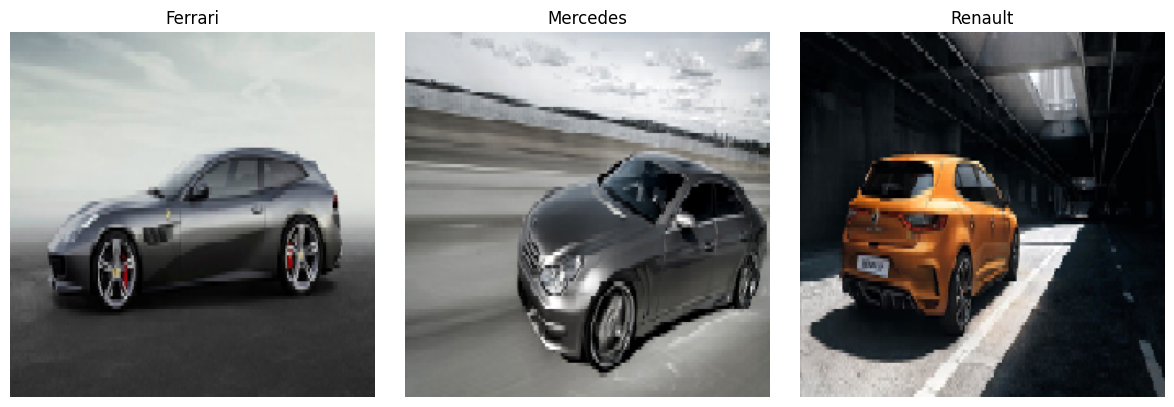

In [6]:
# Просмотр по одному изображению из каждого класса
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(4*CLASS_COUNT, 4))
if CLASS_COUNT == 1:
    axs = [axs]

for i in range(CLASS_COUNT):
    idx = np.where(labels == i)[0][0]
    axs[i].imshow(images[idx].astype('uint8'))
    axs[i].set_title(CLASS_LIST[i])
    axs[i].axis('off')
plt.tight_layout()
plt.show()

## Разделение на train / val / test со стратификацией

In [7]:
# Сначала отделяем тестовую выборку
x_train_full, x_test, y_train_full, y_test = train_test_split(
    images, labels,
    test_size=TEST_SPLIT,
    random_state=42,
    stratify=labels
)

# Затем делим на обучающую и проверочную
x_train, x_val, y_train_raw, y_val_raw = train_test_split(
    x_train_full, y_train_full,
    test_size=VAL_SPLIT,
    random_state=42,
    stratify=y_train_full
)

# OHE
y_train = to_categorical(y_train_raw, num_classes=CLASS_COUNT)
y_val = to_categorical(y_val_raw, num_classes=CLASS_COUNT)
y_test_ohe = to_categorical(y_test, num_classes=CLASS_COUNT)

print(f'Обучающий набор:    {x_train.shape}')
print(f'Проверочный набор:  {x_val.shape}')
print(f'Тестовый набор:     {x_test.shape}')

Обучающий набор:    (2467, 224, 224, 3)
Проверочный набор:  (617, 224, 224, 3)
Тестовый набор:     (343, 224, 224, 3)


In [8]:
# Веса классов на случай дисбаланса
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weight_dict = dict(enumerate(class_weights))
print(f'Веса классов: {class_weight_dict}')

Веса классов: {0: np.float64(1.0502341421881651), 1: np.float64(0.983652312599681), 2: np.float64(0.9697327044025157)}


## Аугментация и подготовка данных

**Важно:** для предобученных моделей вместо стандартной нормализации `1/255` используется `preprocess_input` из `tf.keras.applications.mobilenet_v2`. Эта функция приводит данные к диапазону [-1, 1], в котором обучалась MobileNetV2.

In [9]:
# Генератор для обучения - аугментация + нормализация под MobileNetV2
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Для val и test - только нормализация
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow(x_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
validation_generator = val_datagen.flow(x_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_generator = test_datagen.flow(x_test, y_test_ohe, batch_size=BATCH_SIZE, shuffle=False)

## Создание модели на базе MobileNetV2

**Архитектура:**
1. **MobileNetV2** — предобученная база, без classification-головы
2. **GlobalAveragePooling2D** — преобразует карту признаков в вектор
3. **Dense + Dropout** — новая голова под нашу задачу
4. **Выходной Dense с softmax** — по числу классов

In [10]:
# Загружаем MobileNetV2 без верхнего слоя
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    include_top=False,
    weights='imagenet',
    pooling=None
)

# ЭТАП 1: замораживаем базу
base_model.trainable = False

# Собираем модель
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(CLASS_COUNT, activation='softmax')(x)

model = Model(inputs, outputs)

print(f'Всего параметров:        {model.count_params():,}')
print(f'Обучаемых параметров:    {sum(tf.size(w).numpy() for w in model.trainable_weights):,}')
print(f'Замороженных параметров: {sum(tf.size(w).numpy() for w in model.non_trainable_weights):,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Всего параметров:        2,427,971
Обучаемых параметров:    167,171
Замороженных параметров: 2,260,800


## Этап 1: обучение головы (база заморожена)

С замороженной базой можем использовать высокий learning rate — обучаются только новые слои.

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage1 = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-5, verbose=1)
]

history_stage1 = model.fit(
    train_generator,
    epochs=EPOCHS_FROZEN,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1,
    verbose=1
)

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 83s 790ms/step - accuracy: 0.6838 - loss: 0.9358 - val_accuracy: 0.7731 - val_loss: 0.5191 - learning_rate: 0.0010
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 433ms/step - accuracy: 0.7584 - loss: 0.6599 - val_accuracy: 0.8006 - val_loss: 0.4792 - learning_rate: 0.0010
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 440ms/step - accuracy: 0.7916 - loss: 0.5563 - val_accuracy: 0.8185 - val_loss: 0.4499 - learning_rate: 0.0010
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 417ms/step - accuracy: 0.7933 - loss: 0.5123 - val_accuracy: 0.8136 - val_loss: 0.4456 - learning_rate: 0.0010
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 433ms/step - accuracy: 0.8168 - loss: 0.4603 - val_accuracy: 0.8282 - val_loss: 0.4425 - learning_rate: 0.0010
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 437ms/step - accuracy: 0.8176 - loss: 0.4624 - val_accuracy: 0.8428 - val_loss: 0.4238 - learning_rate: 0.0010
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 424ms/step - accuracy: 0.8229 - loss: 0.

## Этап 2: Fine-tuning (размораживаем верхние слои базы)

Размораживаем верхнюю часть MobileNetV2 и дообучаем всю модель с очень маленьким learning rate. Это позволяет модели адаптировать высокоуровневые признаки под автомобили, не разрушая полезные низкоуровневые признаки.

In [12]:
# Размораживаем базу
base_model.trainable = True

# Замораживаем нижние слои - учим только верхние ~30%
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Перекомпиляция с очень маленьким learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Обучаемых параметров на этапе 2: {trainable_params:,}')

Обучаемых параметров на этапе 2: 2,028,611


In [13]:
callbacks_stage2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)
]

history_stage2 = model.fit(
    train_generator,
    epochs=EPOCHS_FINETUNE,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage2,
    verbose=1
)

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 79s 697ms/step - accuracy: 0.7418 - loss: 0.6344 - val_accuracy: 0.8347 - val_loss: 0.3882 - learning_rate: 1.0000e-05
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 416ms/step - accuracy: 0.7758 - loss: 0.5648 - val_accuracy: 0.8428 - val_loss: 0.4067 - learning_rate: 1.0000e-05
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 429ms/step - accuracy: 0.7819 - loss: 0.5338 - val_accuracy: 0.8412 - val_loss: 0.4058 - learning_rate: 1.0000e-05
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8111 - loss: 0.4669
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 413ms/step - accuracy: 0.8107 - loss: 0.4905 - val_accuracy: 0.8493 - val_loss: 0.3885 - learning_rate: 1.0000e-05
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 419ms/step - accuracy: 0.8026 - loss: 0.4664 - val_accuracy: 0.8541 - val_loss: 0.3740 - learning_rate: 3.0000e-06
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 412ms/step - accuracy

## График обучения

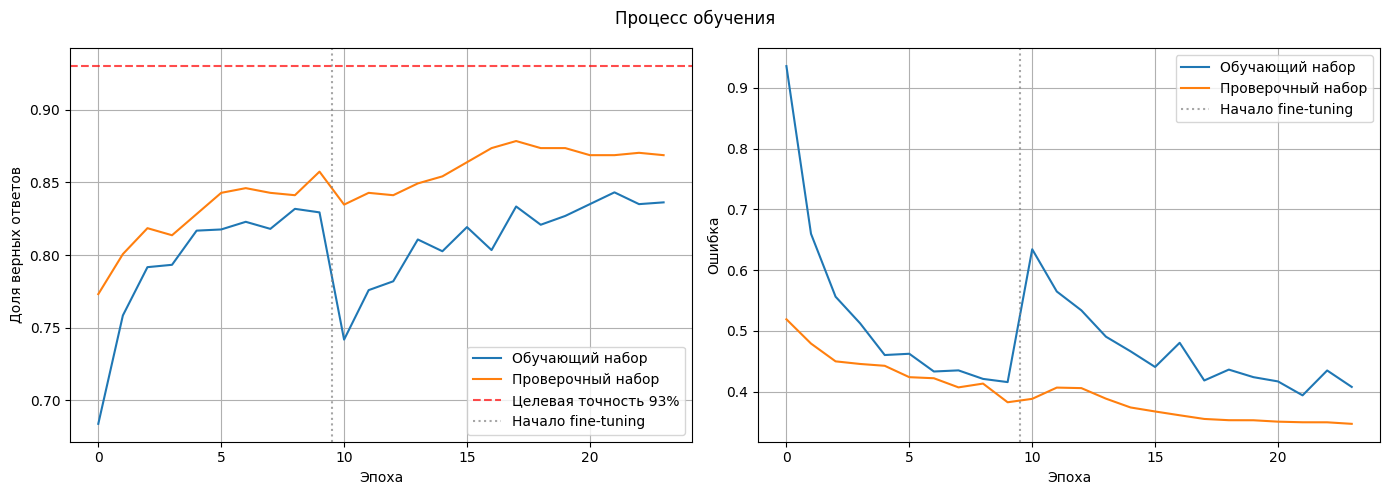


Лучшая точность на проверочной выборке: 0.8784 (87.84%)
Цель пока не достигнута


In [14]:
# Объединяем историю обоих этапов
acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
loss = history_stage1.history['loss'] + history_stage2.history['loss']
val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']

stage1_end = len(history_stage1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Процесс обучения')

ax1.plot(acc, label='Обучающий набор')
ax1.plot(val_acc, label='Проверочный набор')
ax1.axhline(y=0.93, color='r', linestyle='--', alpha=0.7, label='Целевая точность 93%')
ax1.axvline(x=stage1_end - 0.5, color='gray', linestyle=':', alpha=0.7, label='Начало fine-tuning')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Доля верных ответов')
ax1.legend()
ax1.grid(True)

ax2.plot(loss, label='Обучающий набор')
ax2.plot(val_loss, label='Проверочный набор')
ax2.axvline(x=stage1_end - 0.5, color='gray', linestyle=':', alpha=0.7, label='Начало fine-tuning')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Ошибка')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

best_val_acc = max(val_acc)
print(f'\nЛучшая точность на проверочной выборке: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
if best_val_acc >= 0.93:
    print('Цель достигнута! Точность не ниже 93%')
else:
    print('Цель пока не достигнута')

## Оценка на тестовой выборке

11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step


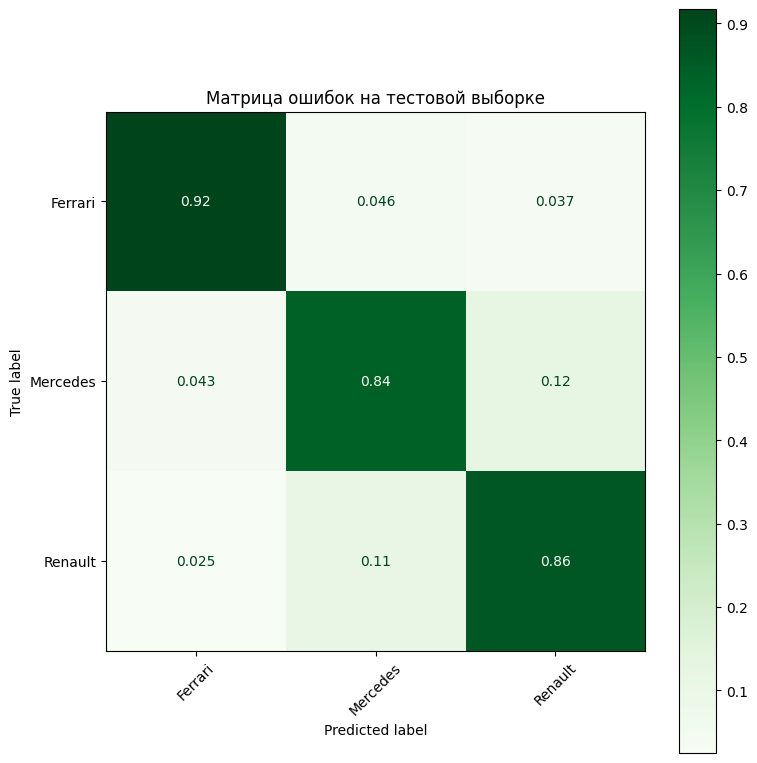


Подробный отчёт по классам:
              precision    recall  f1-score   support

     Ferrari       0.93      0.92      0.92       109
    Mercedes       0.84      0.84      0.84       116
     Renault       0.85      0.86      0.86       118

    accuracy                           0.87       343
   macro avg       0.87      0.87      0.87       343
weighted avg       0.87      0.87      0.87       343



In [15]:
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred_classes, normalize='true')
cm = np.round(cm, 3)

fig, ax = plt.subplots(figsize=(max(8, CLASS_COUNT), max(8, CLASS_COUNT)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
disp.plot(ax=ax, cmap='Greens', colorbar=True, xticks_rotation=45)
plt.title('Матрица ошибок на тестовой выборке')
plt.tight_layout()
plt.show()

print('\nПодробный отчёт по классам:')
print(classification_report(y_true, y_pred_classes, target_names=CLASS_LIST))

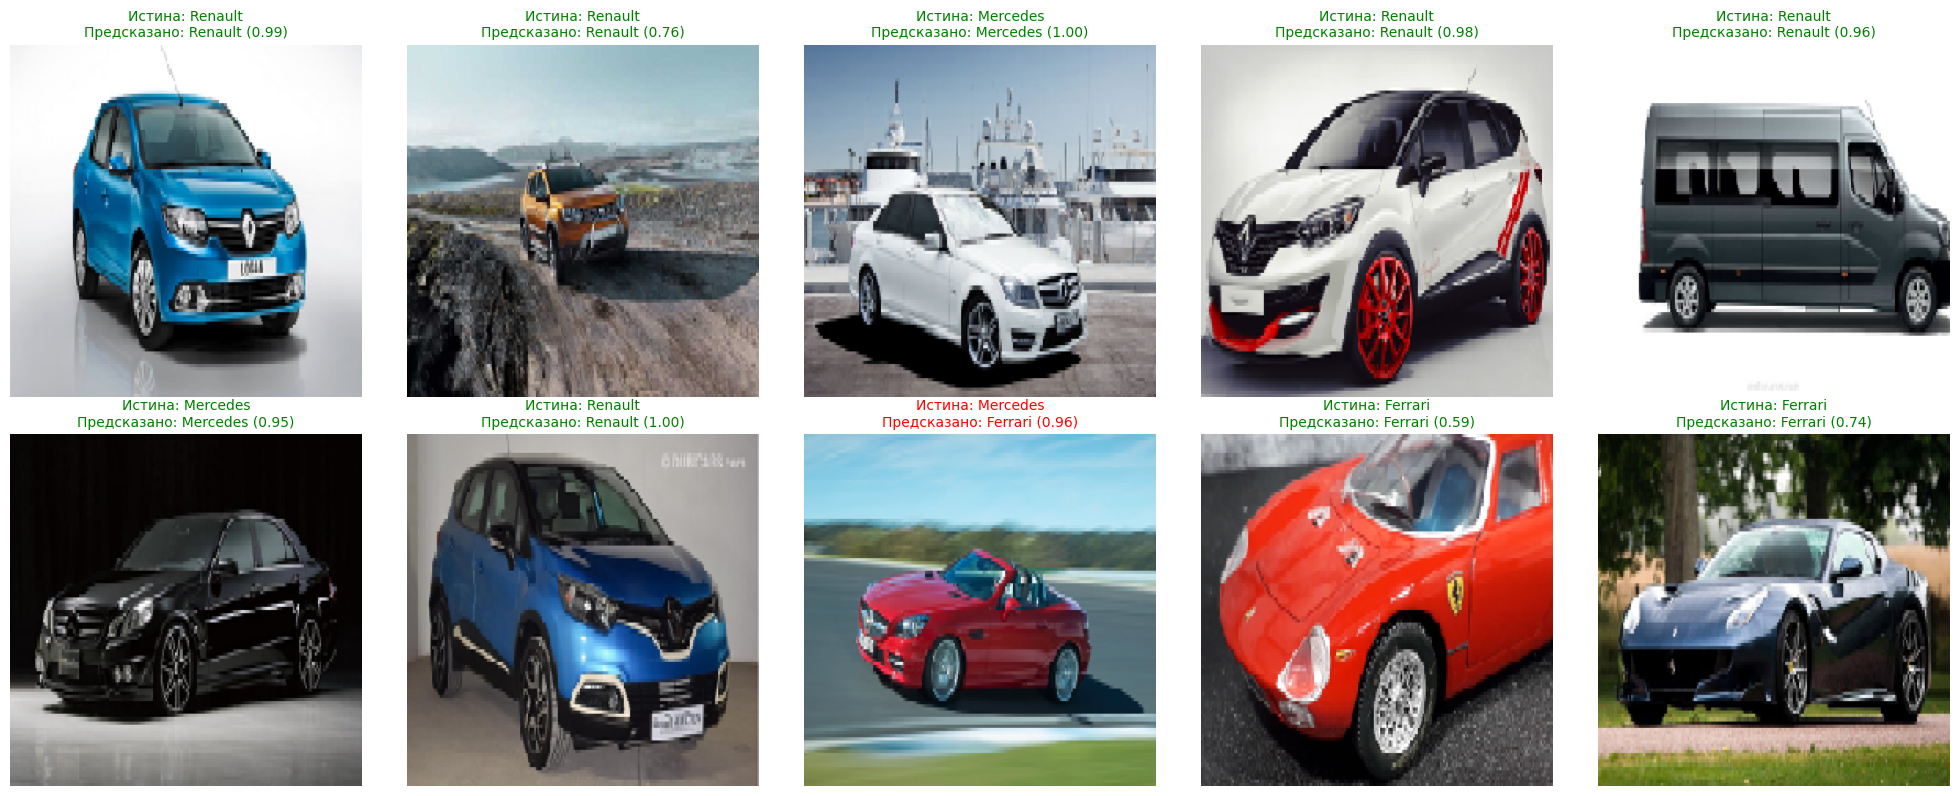

In [16]:
# Просмотр предсказаний на случайных примерах
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
axs = axs.flatten()

indices = random.sample(range(len(x_test)), 10)
for i, idx in enumerate(indices):
    img = x_test[idx].astype('uint8')
    true_label = CLASS_LIST[y_test[idx]]
    pred_label = CLASS_LIST[y_pred_classes[idx]]
    pred_proba = y_pred[idx][y_pred_classes[idx]]

    color = 'green' if true_label == pred_label else 'red'
    axs[i].imshow(img)
    axs[i].set_title(f'Истина: {true_label}\nПредсказано: {pred_label} ({pred_proba:.2f})',
                     color=color, fontsize=10)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Сохранение модели
model.save('cars_mobilenetv2.keras')
print('Модель сохранена в cars_mobilenetv2.keras')

Модель сохранена в cars_mobilenetv2.keras


---

# Сравнение со старой архитектурой: VGG16

обучим ту же задачу на классической **VGG16** (Simonyan & Zisserman, 2014). VGG — это «дотрансформерная классика»: одинаковые блоки из свёрток 3×3 + max-pooling, без residual-связей, без depthwise-свёрток. Простая, понятная, и при этом — **138 миллионов параметров** против ~3.5М у MobileNetV2.

**Что важно для честного сравнения:**
- та же двухэтапная схема fine-tuning (заморозка → разморозка верхушки)
- те же выборки train/val/test, те же `class_weight`
- но **СВОЙ** `preprocess_input` — VGG16 использует другую нормализацию (вычитание средних BGR ImageNet), не такую как MobileNetV2 (приведение к `[-1, 1]`)
- **СВОИ** генераторы данных, переcозданные с правильным препроцессингом


In [18]:
#  Импорты для VGG16
from tensorflow.keras.applications import VGG16
# ВАЖНО: у VGG16 свой preprocess_input — отличается от MobileNetV2
# Импортируем его под отдельным именем, чтобы не конфликтовал с уже импортированным выше.
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess_input

#  Свои генераторы данных под VGG16
# Используем те же x_train/x_val/x_test, что и для MobileNetV2 (стратификация и веса классов те же),
vgg_train_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True,
    fill_mode='nearest',
)
vgg_val_datagen  = ImageDataGenerator(preprocessing_function=vgg_preprocess_input)
vgg_test_datagen = ImageDataGenerator(preprocessing_function=vgg_preprocess_input)

vgg_train_generator      = vgg_train_datagen.flow(x_train, y_train,     batch_size=BATCH_SIZE, shuffle=True)
vgg_validation_generator = vgg_val_datagen.flow(x_val,    y_val,        batch_size=BATCH_SIZE, shuffle=False)
vgg_test_generator       = vgg_test_datagen.flow(x_test,  y_test_ohe,   batch_size=BATCH_SIZE, shuffle=False)

print('Генераторы для VGG16 готовы')


Генераторы для VGG16 готовы


In [19]:
#  Создаём модель на базе VGG16
vgg_base = VGG16(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    include_top=False,
    weights='imagenet',
    pooling=None,
)

# ЭТАП 1: замораживаем всю VGG16
vgg_base.trainable = False

# Голова модели
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
x = vgg_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(CLASS_COUNT, activation='softmax')(x)

vgg_model = Model(inputs, outputs)

print(f'VGG16 — Всего параметров:        {vgg_model.count_params():,}')
print(f'VGG16 — Обучаемых параметров:    {sum(tf.size(w).numpy() for w in vgg_model.trainable_weights):,}')
print(f'VGG16 — Замороженных параметров: {sum(tf.size(w).numpy() for w in vgg_model.non_trainable_weights):,}')
print()
print('Структура VGG16 (последние слои):')
for i, layer in enumerate(vgg_base.layers[-8:]):
    print(f'  {len(vgg_base.layers) - 8 + i:2d}: {layer.name:30s} trainable={layer.trainable}')


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 — Всего параметров:        14,783,299
VGG16 — Обучаемых параметров:    67,331
VGG16 — Замороженных параметров: 14,715,968

Структура VGG16 (последние слои):
  11: block4_conv1                   trainable=False
  12: block4_conv2                   trainable=False
  13: block4_conv3                   trainable=False
  14: block4_pool                    trainable=False
  15: block5_conv1                   trainable=False
  16: block5_conv2                   trainable=False
  17: block5_conv3                   trainable=False
  18: block5_pool                    trainable=False


### VGG16 — Этап 1: обучение головы (база заморожена)


In [20]:
vgg_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

vgg_callbacks_s1 = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-5, verbose=1),
]

import time
t0 = time.time()
vgg_history_s1 = vgg_model.fit(
    vgg_train_generator,
    epochs=EPOCHS_FROZEN,
    validation_data=vgg_validation_generator,
    class_weight=class_weight_dict,
    callbacks=vgg_callbacks_s1,
    verbose=1,
)
vgg_time_stage1 = time.time() - t0
print(f'\nЭтап 1 для VGG16 занял: {vgg_time_stage1:.1f} сек')


Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 73s 675ms/step - accuracy: 0.5825 - loss: 1.0752 - val_accuracy: 0.7731 - val_loss: 0.6205 - learning_rate: 0.0010
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 532ms/step - accuracy: 0.7102 - loss: 0.7352 - val_accuracy: 0.8055 - val_loss: 0.5251 - learning_rate: 0.0010
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 539ms/step - accuracy: 0.7345 - loss: 0.6230 - val_accuracy: 0.8314 - val_loss: 0.4545 - learning_rate: 0.0010
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 50s 648ms/step - accuracy: 0.7612 - loss: 0.5760 - val_accuracy: 0.8201 - val_loss: 0.4440 - learning_rate: 0.0010
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 87s 706ms/step - accuracy: 0.7734 - loss: 0.5565 - val_accuracy: 0.8250 - val_loss: 0.4150 - learning_rate: 0.0010
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 61s 770ms/step - accuracy: 0.7961 - loss: 0.5082 - val_accuracy: 0.8266 - val_loss: 0.4175 - learning_rate: 0.0010
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 59s 763ms/step - accuracy: 0.7839 - loss: 0.

### VGG16 — Этап 2: разморозка верхних слоёв (fine-tuning)

У VGG16 13 свёрточных слоёв в 5 блоках. Размораживаем только последний свёрточный блок (`block5_conv1`, `block5_conv2`, `block5_conv3`) — это аналог разморозки «верхних 30%», как делали для MobileNetV2.


In [21]:
# Размораживаем верхушку VGG16
vgg_base.trainable = True

# Замораживаем все слои, кроме последнего свёрточного блока (block5_*)
for layer in vgg_base.layers:
    if not layer.name.startswith('block5'):
        layer.trainable = False

# Перекомпилируем с очень маленьким lr
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

trainable = sum(tf.size(w).numpy() for w in vgg_model.trainable_weights)
print(f'VGG16 — обучаемых параметров на этапе 2: {trainable:,}')

vgg_callbacks_s2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
]

t0 = time.time()
vgg_history_s2 = vgg_model.fit(
    vgg_train_generator,
    epochs=EPOCHS_FINETUNE,
    validation_data=vgg_validation_generator,
    class_weight=class_weight_dict,
    callbacks=vgg_callbacks_s2,
    verbose=1,
)
vgg_time_stage2 = time.time() - t0
print(f'\nЭтап 2 для VGG16 занял: {vgg_time_stage2:.1f} сек')


VGG16 — обучаемых параметров на этапе 2: 7,146,755
Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 58s 604ms/step - accuracy: 0.8176 - loss: 0.4476 - val_accuracy: 0.8655 - val_loss: 0.3646 - learning_rate: 1.0000e-05
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 43s 553ms/step - accuracy: 0.8557 - loss: 0.3716 - val_accuracy: 0.8833 - val_loss: 0.3116 - learning_rate: 1.0000e-05
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 44s 568ms/step - accuracy: 0.8622 - loss: 0.3508 - val_accuracy: 0.8865 - val_loss: 0.2844 - learning_rate: 1.0000e-05
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 542ms/step - accuracy: 0.8841 - loss: 0.3063 - val_accuracy: 0.8979 - val_loss: 0.2778 - learning_rate: 1.0000e-05
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 537ms/step - accuracy: 0.8845 - loss: 0.2863 - val_accuracy: 0.8963 - val_loss: 0.2723 - learning_rate: 1.0000e-05
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 536ms/step - accuracy: 0.9027 - loss: 0.2601 - val_accuracy: 0.9092 - val_loss: 0.2619 - learning_rate: 1.0000e-05
Epoch 7

### VGG16 — оценка на тестовой выборке


11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step
VGG16 — точность на тестовой выборке: 91.25%


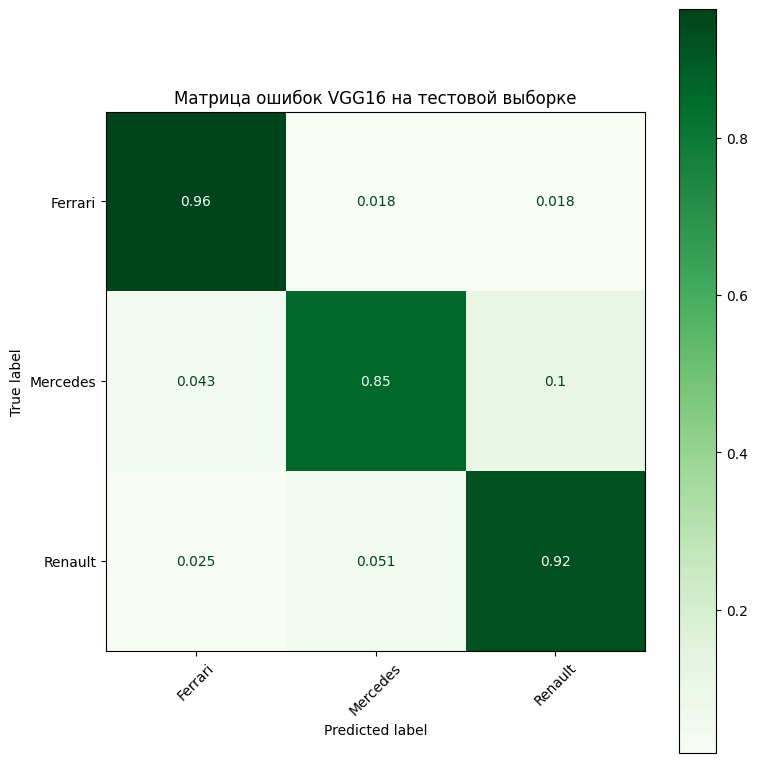

In [22]:
# Предсказания VGG16 на тестовой выборке
vgg_test_generator.reset()
vgg_y_pred = vgg_model.predict(vgg_test_generator)
vgg_y_pred_classes = np.argmax(vgg_y_pred, axis=1)

# Точность на тестовой
vgg_test_acc = np.mean(vgg_y_pred_classes == y_test)
print(f'VGG16 — точность на тестовой выборке: {vgg_test_acc*100:.2f}%')

# Матрица ошибок
cm_vgg = confusion_matrix(y_test, vgg_y_pred_classes, normalize='true')
cm_vgg = np.round(cm_vgg, 3)

fig, ax = plt.subplots(figsize=(max(8, CLASS_COUNT), max(8, CLASS_COUNT)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=CLASS_LIST)
disp.plot(ax=ax, cmap='Greens', colorbar=True, xticks_rotation=45)
plt.title('Матрица ошибок VGG16 на тестовой выборке')
plt.tight_layout()
plt.show()


---

# Итоговое сравнение моделей: MobileNetV2 vs VGG16


In [25]:
import time

#  Собираем метрики для обеих моделей

#  MobileNetV2 (используем переменные из верхней части ноутбука)
# Точность на тесте
mn_test_acc = np.mean(y_pred_classes == y_test)
# Лучшая val_accuracy за весь процесс обучения
mn_best_val = max(
    history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
)
# Параметры
mn_total_params = model.count_params()

#  VGG16
vgg_best_val = max(
    vgg_history_s1.history['val_accuracy'] + vgg_history_s2.history['val_accuracy']
)
vgg_total_params = vgg_model.count_params()

#  Замер времени инференса
# Берём 5 батчей и усредняем — для надёжности
def measure_inference_time(model, generator, n_batches=5):
    generator.reset()
    times = []
    for i, (batch_x, _) in enumerate(generator):
        if i >= n_batches:
            break
        t0 = time.time()
        _ = model.predict(batch_x, verbose=0)
        times.append(time.time() - t0)
    return np.mean(times) * 1000  # в миллисекундах на батч

mn_inference_ms  = measure_inference_time(model,     test_generator)
vgg_inference_ms = measure_inference_time(vgg_model, vgg_test_generator)

#  таблица сравнения
print(f'{"Метрика":<35} {"MobileNetV2":>18} {"VGG16":>18}')
print(f'{"Год архитектуры":<35} {2018:>18} {2014:>18}')
print(f'{"Всего параметров":<35} {mn_total_params:>18,} {vgg_total_params:>18,}')
print(f'{"Размер модели (приблиз.)":<35} {mn_total_params*4/1024/1024:>17.1f}M {vgg_total_params*4/1024/1024:>17.1f}M')
print(f'{"Лучшая точность на val":<35} {mn_best_val*100:>17.2f}% {vgg_best_val*100:>17.2f}%')
print(f'{"Точность на тестовой выборке":<35} {mn_test_acc*100:>17.2f}% {vgg_test_acc*100:>17.2f}%')
print(f'{"Среднее время инференса батча":<35} {mn_inference_ms:>16.1f}мс {vgg_inference_ms:>16.1f}мс')
print(f'{"Во сколько раз медленнее VGG":<35} {1.0:>17.1f}x {vgg_inference_ms/mn_inference_ms:>17.1f}x')


Метрика                                    MobileNetV2              VGG16
Год архитектуры                                   2018               2014
Всего параметров                             2,427,971         14,783,299
Размер модели (приблиз.)                          9.3M              56.4M
Лучшая точность на val                          87.84%             93.19%
Точность на тестовой выборке                    87.17%             91.25%
Среднее время инференса батча                  116.6мс            268.0мс
Во сколько раз медленнее VGG                      1.0x               2.3x


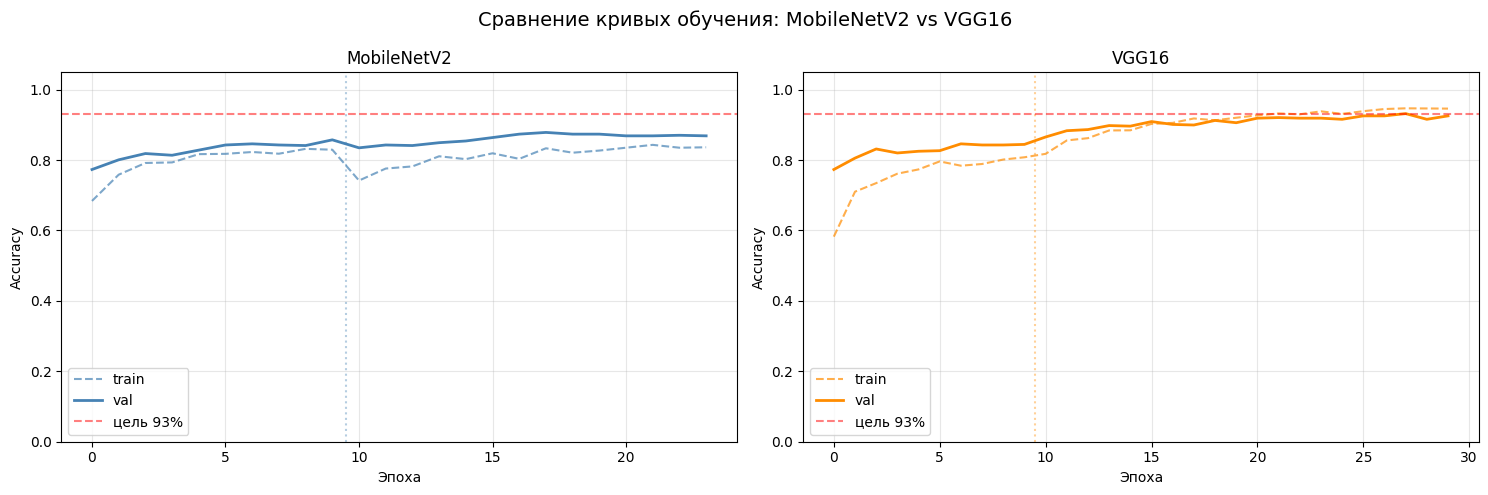

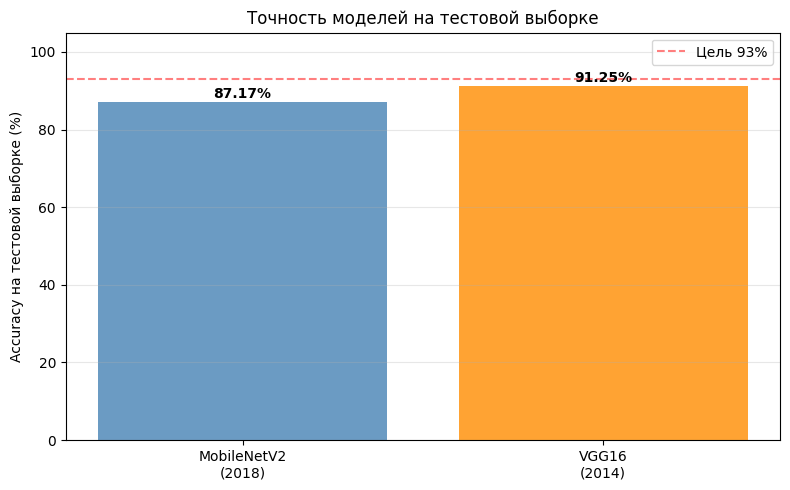

In [24]:
#  Визуальное сравнение кривых обучения

# История MobileNetV2
mn_acc     = history_stage1.history['accuracy']     + history_stage2.history['accuracy']
mn_val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
mn_stage_boundary = len(history_stage1.history['accuracy']) - 0.5

# История VGG16
vgg_acc     = vgg_history_s1.history['accuracy']     + vgg_history_s2.history['accuracy']
vgg_val_acc = vgg_history_s1.history['val_accuracy'] + vgg_history_s2.history['val_accuracy']
vgg_stage_boundary = len(vgg_history_s1.history['accuracy']) - 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Сравнение кривых обучения: MobileNetV2 vs VGG16', fontsize=14)

# MobileNetV2
ax1.plot(mn_acc,     label='train',  color='steelblue', linestyle='--', alpha=0.7)
ax1.plot(mn_val_acc, label='val',    color='steelblue', linewidth=2)
ax1.axvline(x=mn_stage_boundary, color='steelblue', linestyle=':', alpha=0.4)
ax1.axhline(y=0.93, color='r', linestyle='--', alpha=0.5, label='цель 93%')
ax1.set_title('MobileNetV2')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# VGG16
ax2.plot(vgg_acc,     label='train', color='darkorange', linestyle='--', alpha=0.7)
ax2.plot(vgg_val_acc, label='val',   color='darkorange', linewidth=2)
ax2.axvline(x=vgg_stage_boundary, color='darkorange', linestyle=':', alpha=0.4)
ax2.axhline(y=0.93, color='r', linestyle='--', alpha=0.5, label='цель 93%')
ax2.set_title('VGG16')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

#  точность на тесте
fig, ax = plt.subplots(figsize=(8, 5))
models_names = ['MobileNetV2\n(2018)', 'VGG16\n(2014)']
test_accs = [mn_test_acc * 100, vgg_test_acc * 100]
colors = ['steelblue', 'darkorange']
bars = ax.bar(models_names, test_accs, color=colors, alpha=0.8)
ax.axhline(y=93, color='r', linestyle='--', alpha=0.5, label='Цель 93%')
ax.set_ylabel('Accuracy на тестовой выборке (%)')
ax.set_title('Точность моделей на тестовой выборке')
ax.set_ylim(0, 105)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Подписи на столбиках
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
